#### 05 · Multi-Target Price Forecasting
Forecast next month's **Min / Avg / Max price** per product.

**Flow:** Setup → Split → Baseline → Random Forest (Optuna) → LightGBM (Optuna) → Validation comparison → Final Test/Forecast.

Error analysis (category/unit/volatility/SHAP) is done in a **separate notebook** using `results/validation_month_9_predictions.csv` and `results/month_11_forecast.csv`.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import lightgbm as lgb

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

RANDOM_STATE = 42
N_TRIALS = 50

os.makedirs("results", exist_ok=True)
os.makedirs("plots", exist_ok=True)

/Users/bruker/Desktop/Multi-Target Price Forecasting /.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load cleaned dataset
data_path = "data/all_months_features.csv"
if not os.path.exists(data_path):
    raise FileNotFoundError(f"File not found: {data_path}")

df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape}")
print(f"Number of products: {df['Product_Name'].nunique()}")

Dataset shape: (798, 77)
Number of products: 95


In [3]:
##  Month Index & Next-Month Targets
# Chronological month index per product
df = df.sort_values(["Product_Name"]).reset_index(drop=True)
df["month_idx"] = df.groupby("Product_Name").cumcount() + 1
df = df.sort_values(["Product_Name", "month_idx"]).reset_index(drop=True)

# Targets = next month's Min/Avg/Max price (shift -1 within each product)
targets_base = ["Min_Price", "Avg_Price", "Max_Price"]
targets_next = ["Min_Price_next", "Avg_Price_next", "Max_Price_next"]
for base, nxt in zip(targets_base, targets_next):
    df[nxt] = df.groupby("Product_Name")[base].shift(-1)

print(df.groupby("month_idx")["Product_Name"].nunique().to_string())

month_idx
1     95
2     91
3     90
4     89
5     85
6     83
7     80
8     71
9     64
10    50


#####  Time-Based Split
- **Train:** Month 1–8  
- **Validation:** Month 9 → predicts Month 10 (used to pick the best model)  
- **Test/Forecast input:** Month 10 → predicts Month 11 (final deliverable)

In [4]:
train_df = df[df["month_idx"] <= 8].dropna(subset=targets_next).copy()
valid_df = df[df["month_idx"] == 9].dropna(subset=targets_next).copy()
test_df  = df[df["month_idx"] == 10].copy()

print(f"Training   Month 1-8 : {len(train_df)}")
print(f"Validation Month 9   : {len(valid_df)}  (target = Month 10)")
print(f"Test/Input Month 10  : {len(test_df)}  (target = Month 11)")

Training   Month 1-8 : 591
Validation Month 9   : 48  (target = Month 10)
Test/Input Month 10  : 50  (target = Month 11)


In [5]:
# Feature matrix (exclude identifiers, dates, and all target columns)
non_feature_cols = ["Product_Name", "Category", "Unit", "unit_canonical", "month_name",
                     "bs_year", "bs_month", "month_idx"] + targets_base + targets_next
feature_cols = [c for c in df.columns if c not in non_feature_cols]

X_train = train_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y_train = train_df[targets_next]

X_valid = valid_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y_valid = valid_df[targets_next]

X_test = test_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

print(f"Number of features: {len(feature_cols)}")
print(f"X_train: {X_train.shape} | X_valid: {X_valid.shape} | X_test: {X_test.shape}")

Number of features: 66
X_train: (591, 66) | X_valid: (48, 66) | X_test: (50, 66)


##### Helper Functions

In [6]:
def apply_constraint(pred):
    # Enforce Min <= Avg <= Max on any prediction array
    pred = np.asarray(pred).copy()
    pred[:, 0] = np.minimum(pred[:, 0], pred[:, 1])
    pred[:, 2] = np.maximum(pred[:, 2], pred[:, 1])
    return pred

def regression_metrics(actual, pred):
    # MAE / RMSE / MAPE / R2 per target
    results = []
    for i, target in enumerate(targets_next):
        a, p = actual.iloc[:, i].values, pred[:, i]
        results.append({
            "Target": target,
            "MAE": mean_absolute_error(a, p),
            "RMSE": np.sqrt(mean_squared_error(a, p)),
            "MAPE (%)": mean_absolute_percentage_error(a, p) * 100,
            "R²": r2_score(a, p)
        })
    return pd.DataFrame(results)

print("Helper functions ready.")

Helper functions ready.


##### Baseline (Last-Value Persistence)
Baseline = this month's price carried forward as next month's prediction.

In [7]:
baseline_valid = np.column_stack([
    X_valid["Min_Price_lag1"].values,
    X_valid["Avg_Price_lag1"].values,
    X_valid["Max_Price_lag1"].values
])
baseline_valid = apply_constraint(baseline_valid)
baseline_valid_metrics = regression_metrics(y_valid, baseline_valid)

print("BASELINE VALIDATION: MONTH 9 → MONTH 10")
print(baseline_valid_metrics.round(2).to_string(index=False))

BASELINE VALIDATION: MONTH 9 → MONTH 10
        Target    MAE   RMSE  MAPE (%)    R²
Min_Price_next  80.04 114.02     70.54 -1.18
Avg_Price_next 102.24 142.46     66.60 -0.88
Max_Price_next 124.62 178.11     63.99 -0.64


##### Random Forest — Optuna Tuning

In [8]:
def rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": RANDOM_STATE, "n_jobs": -1
    }
    model = MultiOutputRegressor(RandomForestRegressor(**params))
    model.fit(X_train, y_train)
    pred = apply_constraint(model.predict(X_valid))
    rmse = [np.sqrt(mean_squared_error(y_valid.iloc[:, i], pred[:, i])) for i in range(3)]
    return np.mean(rmse)

rf_study = optuna.create_study(direction="minimize", study_name="RandomForest_Price_Forecasting")
rf_study.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best RF Validation RMSE:", round(rf_study.best_value, 4))
print("Best RF Parameters:", rf_study.best_params)

[I 2026-08-17 10:59:20,660] A new study created in memory with name: RandomForest_Price_Forecasting
Best trial: 0. Best value: 77.2031:   2%|▏         | 1/50 [00:01<01:06,  1.36s/it]

[I 2026-08-17 10:59:22,036] Trial 0 finished with value: 77.2030974269136 and parameters: {'n_estimators': 350, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 77.2030974269136.


Best trial: 1. Best value: 65.171:   4%|▍         | 2/50 [00:05<02:30,  3.14s/it] 

[I 2026-08-17 10:59:26,419] Trial 1 finished with value: 65.17096566067102 and parameters: {'n_estimators': 500, 'max_depth': 21, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 1.0, 'bootstrap': False}. Best is trial 1 with value: 65.17096566067102.


Best trial: 2. Best value: 59.0815:   6%|▌         | 3/50 [00:10<03:00,  3.85s/it]

...

[I 2026-08-17 11:01:07,376] Trial 47 finished with value: 85.40334684944946 and parameters: {'n_estimators': 250, 'max_depth': 3, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 41 with value: 55.48845072124283.


Best trial: 41. Best value: 55.4885:  98%|█████████▊| 49/50 [01:49<00:02,  2.02s/it]

[I 2026-08-17 11:01:10,329] Trial 48 finished with value: 58.8897297529057 and parameters: {'n_estimators': 350, 'max_depth': 21, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.5, 'bootstrap': False}. Best is trial 41 with value: 55.48845072124283.


Best trial: 41. Best value: 55.4885: 100%|██████████| 50/50 [01:50<00:00,  2.21s/it]

[I 2026-08-17 11:01:11,200] Trial 49 finished with value: 70.96389435707066 and parameters: {'n_estimators': 200, 'max_depth': 22, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False}. Best is trial 41 with value: 55.48845072124283.
Best RF Validation RMSE: 55.4885
Best RF Parameters: {'n_estimators': 250, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 0.5, 'bootstrap': False}


##### LightGBM — Optuna Tuning

In [9]:
def lgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 10, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": -1
    }
    model = MultiOutputRegressor(lgb.LGBMRegressor(**params))
    model.fit(X_train, y_train)
    pred = apply_constraint(model.predict(X_valid))
    rmse = [np.sqrt(mean_squared_error(y_valid.iloc[:, i], pred[:, i])) for i in range(3)]
    return np.mean(rmse)

lgb_study = optuna.create_study(direction="minimize", study_name="LightGBM_Price_Forecasting")
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best LightGBM Validation RMSE:", round(lgb_study.best_value, 4))
print("Best LightGBM Parameters:", lgb_study.best_params)

[I 2026-08-17 11:01:11,262] A new study created in memory with name: LightGBM_Price_Forecasting
Best trial: 0. Best value: 55.8837:   2%|▏         | 1/50 [00:02<01:57,  2.41s/it]

[I 2026-08-17 11:01:13,690] Trial 0 finished with value: 55.88373158779961 and parameters: {'n_estimators': 700, 'learning_rate': 0.019021304649434287, 'num_leaves': 99, 'max_depth': 12, 'min_child_samples': 14, 'subsample': 0.8807962159224869, 'colsample_bytree': 0.7237490049844008, 'reg_alpha': 0.002118689076242146, 'reg_lambda': 5.60218573848329e-05}. Best is trial 0 with value: 55.88373158779961.


Best trial: 1. Best value: 55.2804:   4%|▍         | 2/50 [00:02<00:55,  1.15s/it]

[I 2026-08-17 11:01:13,955] Trial 1 finished with value: 55.28039008618529 and parameters: {'n_estimators': 250, 'learning_rate': 0.12983435726853645, 'num_leaves': 30, 'max_depth': 3, 'min_child_samples': 17, 'subsample': 0.7905074379643713, 'colsample_bytree': 0.9699871769504791, 'reg_alpha': 0.005014349594761375, 'reg_lambda': 0.0002687783360618658}. Best is trial 1 with value: 55.28039008618529.


Best trial: 1. Best value: 55.2804:   6%|▌         | 3/50 [00:04<01:05,  1.40s/it]

...

[I 2026-08-17 11:02:08,720] Trial 47 finished with value: 60.18141459897091 and parameters: {'n_estimators': 200, 'learning_rate': 0.026552482028161992, 'num_leaves': 11, 'max_depth': 14, 'min_child_samples': 10, 'subsample': 0.9904753998125584, 'colsample_bytree': 0.8932983527312542, 'reg_alpha': 0.025498016371741348, 'reg_lambda': 1.4543699340704416e-08}. Best is trial 24 with value: 52.08187952243145.


Best trial: 24. Best value: 52.0819:  98%|█████████▊| 49/50 [00:58<00:00,  1.42it/s]

[I 2026-08-17 11:02:09,462] Trial 48 finished with value: 53.47394436940397 and parameters: {'n_estimators': 550, 'learning_rate': 0.020286027587163816, 'num_leaves': 32, 'max_depth': 4, 'min_child_samples': 7, 'subsample': 0.7639752420381128, 'colsample_bytree': 0.8233125957353776, 'reg_alpha': 2.7501102980832255, 'reg_lambda': 0.31583385651707163}. Best is trial 24 with value: 52.08187952243145.


Best trial: 24. Best value: 52.0819: 100%|██████████| 50/50 [00:59<00:00,  1.19s/it]

[I 2026-08-17 11:02:10,700] Trial 49 finished with value: 53.630817747450266 and parameters: {'n_estimators': 550, 'learning_rate': 0.02134421403002473, 'num_leaves': 90, 'max_depth': 6, 'min_child_samples': 8, 'subsample': 0.7010890404154847, 'colsample_bytree': 0.8744633347936325, 'reg_alpha': 3.181341479317021, 'reg_lambda': 0.3568588205846781}. Best is trial 24 with value: 52.08187952243145.
Best LightGBM Validation RMSE: 52.0819
Best LightGBM Parameters: {'n_estimators': 550, 'learning_rate': 0.046918702341836004, 'num_leaves': 26, 'max_depth': 4, 'min_child_samples': 5, 'subsample': 0.909404652120299, 'colsample_bytree': 0.7629085050349708, 'reg_alpha': 0.024083498751205173, 'reg_lambda': 9.830858958246049}


##### Validation Performance — Baseline vs Random Forest vs LightGBM

In [10]:
rf_params = {**rf_study.best_params, "random_state": RANDOM_STATE, "n_jobs": -1}
rf_valid_model = MultiOutputRegressor(RandomForestRegressor(**rf_params))
rf_valid_model.fit(X_train, y_train)
rf_valid_pred = apply_constraint(rf_valid_model.predict(X_valid))

lgb_params = {**lgb_study.best_params, "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": -1}
lgb_valid_model = MultiOutputRegressor(lgb.LGBMRegressor(**lgb_params))
lgb_valid_model.fit(X_train, y_train)
lgb_valid_pred = apply_constraint(lgb_valid_model.predict(X_valid))

# Keep these as DataFrames 
rf_valid_metrics = regression_metrics(y_valid, rf_valid_pred).round(2)
lgb_valid_metrics = regression_metrics(y_valid, lgb_valid_pred).round(2)

print("RANDOM FOREST VALIDATION")
print(rf_valid_metrics.to_string(index=False))
print("\nLIGHTGBM VALIDATION")
print(lgb_valid_metrics.to_string(index=False))

RANDOM FOREST VALIDATION
        Target   MAE  RMSE  MAPE (%)   R²
Min_Price_next 39.46 52.93     48.89 0.53
Avg_Price_next 41.47 53.38     34.61 0.74
Max_Price_next 41.50 60.16     26.25 0.81

LIGHTGBM VALIDATION
        Target   MAE  RMSE  MAPE (%)   R²
Min_Price_next 36.51 50.76     41.86 0.57
Avg_Price_next 39.10 50.71     28.84 0.76
Max_Price_next 38.14 54.77     21.92 0.84


In [11]:
# Combined comparison table (only CSV saved for this step)
comparison = []
for i, target in enumerate(targets_next):
    actual = y_valid.iloc[:, i]
    base, rf, lgbm = baseline_valid[:, i], rf_valid_pred[:, i], lgb_valid_pred[:, i]
    base_mae = mean_absolute_error(actual, base)
    rf_mae, lgb_mae = mean_absolute_error(actual, rf), mean_absolute_error(actual, lgbm)
    comparison.append({
        "Target": target,
        "Baseline MAE": base_mae, "RF MAE": rf_mae, "LightGBM MAE": lgb_mae,
        "Baseline RMSE": np.sqrt(mean_squared_error(actual, base)),
        "RF RMSE": np.sqrt(mean_squared_error(actual, rf)),
        "LightGBM RMSE": np.sqrt(mean_squared_error(actual, lgbm)),
        "Baseline R²": r2_score(actual, base), "RF R²": r2_score(actual, rf), "LightGBM R²": r2_score(actual, lgbm),
        "RF Improvement (%)": (base_mae - rf_mae) / base_mae * 100,
        "LightGBM Improvement (%)": (base_mae - lgb_mae) / base_mae * 100
    })

comparison_df = pd.DataFrame(comparison).round(2)
comparison_df.to_csv("results/baseline_vs_rf_vs_lightgbm_validation.csv", index=False)

print("MODEL COMPARISON: MONTH 9 → MONTH 10 (saved: results/baseline_vs_rf_vs_lightgbm_validation.csv)")
print(comparison_df.to_string(index=False))

MODEL COMPARISON: MONTH 9 → MONTH 10 (saved: results/baseline_vs_rf_vs_lightgbm_validation.csv)
        Target  Baseline MAE  RF MAE  LightGBM MAE  Baseline RMSE  RF RMSE  LightGBM RMSE  Baseline R²  RF R²  LightGBM R²  RF Improvement (%)  LightGBM Improvement (%)
Min_Price_next         80.04   39.46         36.51         114.02    52.93          50.76        -1.18   0.53         0.57               50.70                     54.39
Avg_Price_next        102.24   41.47         39.10         142.46    53.38          50.71        -0.88   0.74         0.76               59.43                     61.76
Max_Price_next        124.62   41.50         38.14         178.11    60.16          54.77        -0.64   0.81         0.84               66.70                     69.40


In [12]:
# Persist tuned params so 06_Error_analysis.ipynb can refit the same LightGBM for SHAP
import json
with open("results/lightgbm_best_params.json", "w") as f:
    json.dump(lgb_params, f, indent=2)
print("Saved: results/lightgbm_best_params.json")

Saved: results/lightgbm_best_params.json


#### Actual vs Predicted (Validation)

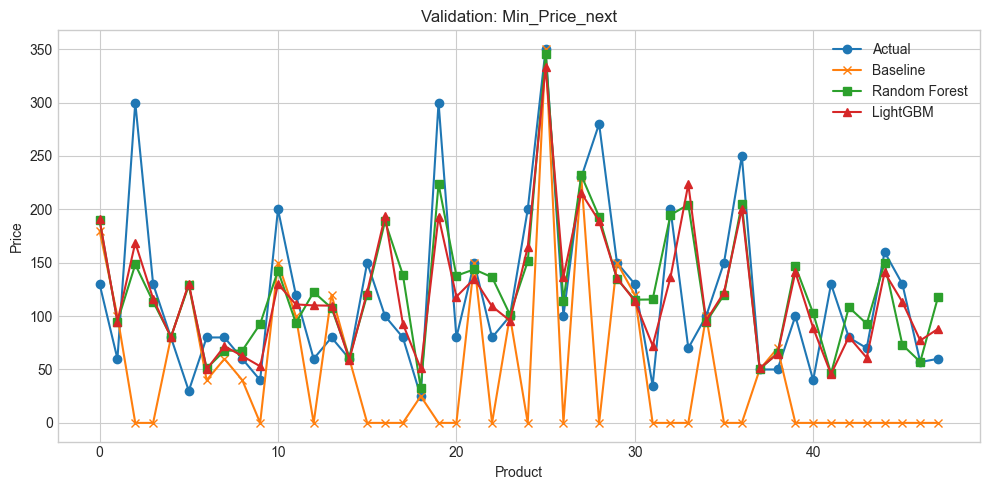

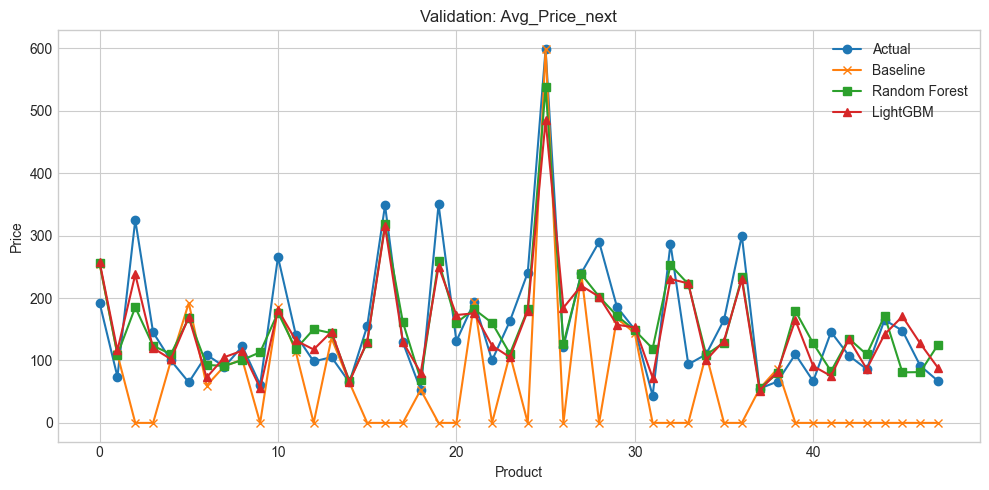

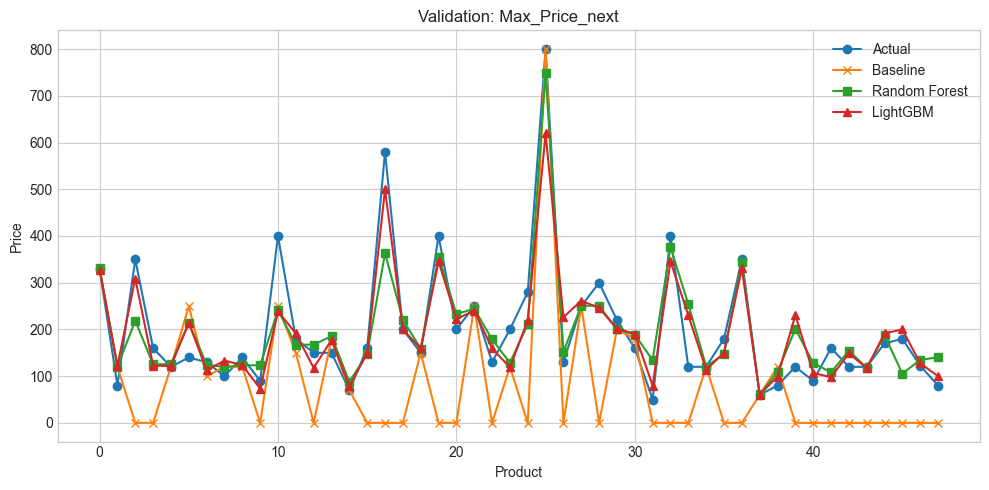

In [13]:
for i, target in enumerate(targets_next):
    plt.figure(figsize=(10, 5))
    plt.plot(y_valid.iloc[:, i].values, marker="o", label="Actual")
    plt.plot(baseline_valid[:, i], marker="x", label="Baseline")
    plt.plot(rf_valid_pred[:, i], marker="s", label="Random Forest")
    plt.plot(lgb_valid_pred[:, i], marker="^", label="LightGBM")
    plt.title(f"Validation: {target}")
    plt.xlabel("Product"); plt.ylabel("Price"); plt.legend(); plt.tight_layout()
    plt.savefig(f"plots/{target}_validation_prediction.png", dpi=300, bbox_inches="tight")
    plt.show()

In [14]:
# Ordering constraint check (Min <= Avg <= Max)
for name, pred in [("Baseline", baseline_valid), ("Random Forest", rf_valid_pred), ("LightGBM", lgb_valid_pred)]:
    violations = (pred[:, 0] > pred[:, 1]) | (pred[:, 1] > pred[:, 2])
    print(f"{name}: {violations.sum()} violations ({violations.mean() * 100:.2f}%)")

Baseline: 0 violations (0.00%)
Random Forest: 0 violations (0.00%)
LightGBM: 0 violations (0.00%)


#### Final Training (Month 1–9) & Month 11 Forecast
Retrain on Train + Validation (Month 1–9), then use Month 10 as input to forecast Month 11.

In [15]:
train_final = pd.concat([train_df, valid_df], ignore_index=True)
X_train_final = train_final[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y_train_final = train_final[targets_next]

rf_final = MultiOutputRegressor(RandomForestRegressor(**rf_params)).fit(X_train_final, y_train_final)
lgb_final = MultiOutputRegressor(lgb.LGBMRegressor(**lgb_params)).fit(X_train_final, y_train_final)

rf_month11 = apply_constraint(rf_final.predict(X_test))
lgb_month11 = apply_constraint(lgb_final.predict(X_test))

baseline_month11 = np.column_stack([X_test["Min_Price_lag1"], X_test["Avg_Price_lag1"], X_test["Max_Price_lag1"]])
baseline_month11 = apply_constraint(baseline_month11)

print(f"Final training rows: {len(train_final)} | Forecast rows (Month 11): {len(test_df)}")

Final training rows: 639 | Forecast rows (Month 11): 50


#### Save Required Outputs
Only two CSVs are produced beyond the validation comparison table:
- `results/month_11_forecast.csv` — final deliverable
- `results/validation_month_9_predictions.csv` — **feeds the separate error-analysis notebook**

In [16]:
forecast_df = test_df[["Product_Name", "month_idx"]].copy().reset_index(drop=True)
forecast_df["Forecast_Month"] = 11
forecast_df[["Baseline_Min_Price", "Baseline_Avg_Price", "Baseline_Max_Price"]] = baseline_month11
forecast_df[["RF_Predicted_Min_Price", "RF_Predicted_Avg_Price", "RF_Predicted_Max_Price"]] = rf_month11
forecast_df[["LightGBM_Predicted_Min_Price", "LightGBM_Predicted_Avg_Price", "LightGBM_Predicted_Max_Price"]] = lgb_month11
forecast_df = forecast_df.round(2)
forecast_df.to_csv("results/month_11_forecast.csv", index=False)

print("Saved: results/month_11_forecast.csv")
print(forecast_df.head(10).to_string(index=False))

Saved: results/month_11_forecast.csv
      Product_Name  month_idx  Forecast_Month  Baseline_Min_Price  Baseline_Avg_Price  Baseline_Max_Price  RF_Predicted_Min_Price  RF_Predicted_Avg_Price  RF_Predicted_Max_Price  LightGBM_Predicted_Min_Price  LightGBM_Predicted_Avg_Price  LightGBM_Predicted_Max_Price
             Apple         10              11                 0.0                0.00                 0.0                  246.89                  363.64                  465.41                        280.48                        391.71                        454.16
              Arum         10              11                60.0               65.26                80.0                   67.38                   73.47                   84.63                         63.28                         71.70                         83.08
           Avocado         10              11               300.0              325.00               350.0                  304.09                  449.28      

In [17]:
validation_results = valid_df[["Product_Name", "month_idx"]].reset_index(drop=True)
for i, target in enumerate(targets_next):
    validation_results[f"Actual_{target}"] = y_valid.iloc[:, i].values
    validation_results[f"Baseline_{target}"] = baseline_valid[:, i]
    validation_results[f"RF_{target}"] = rf_valid_pred[:, i]
    validation_results[f"LightGBM_{target}"] = lgb_valid_pred[:, i]

validation_results = validation_results.round(2)
validation_results.to_csv("results/validation_month_9_predictions.csv", index=False)

print("Saved: results/validation_month_9_predictions.csv  (used for error analysis notebook)")
print(validation_results.head(10).to_string(index=False))

Saved: results/validation_month_9_predictions.csv  (used for error analysis notebook)
      Product_Name  month_idx  Actual_Min_Price_next  Baseline_Min_Price_next  RF_Min_Price_next  LightGBM_Min_Price_next  Actual_Avg_Price_next  Baseline_Avg_Price_next  RF_Avg_Price_next  LightGBM_Avg_Price_next  Actual_Max_Price_next  Baseline_Max_Price_next  RF_Max_Price_next  LightGBM_Max_Price_next
             Apple          9                  130.0                    180.0             189.60                   190.49                 192.40                   255.00             255.69                   258.07                  330.0                    330.0             330.45                   328.19
              Arum          9                   60.0                    100.0              94.81                    94.86                  73.95                   110.00             109.41                   116.25                   80.0                    120.0             120.65                   122

In [18]:
# Validation vs Testing/Forecast — side-by-side comparison
# Validation (Month 9 -> 10): has actual values -> real error metrics
# Testing (Month 10 -> 11): forecast only, no ground truth -> summary stats only

# 1. Validation metrics (already computed: rf_valid_metrics, lgb_valid_metrics, baseline_valid_metrics)
print("VALIDATION — MONTH 9 → MONTH 10 (evaluated against actuals)")
val_summary = pd.concat([
    baseline_valid_metrics.assign(Model="Baseline"),
    rf_valid_metrics.assign(Model="Random Forest"),
    lgb_valid_metrics.assign(Model="LightGBM")
], ignore_index=True)[["Model", "Target", "MAE", "RMSE", "MAPE (%)", "R²"]]
print(val_summary.round(2).to_string(index=False))

VALIDATION — MONTH 9 → MONTH 10 (evaluated against actuals)
        Model         Target    MAE   RMSE  MAPE (%)    R²
     Baseline Min_Price_next  80.04 114.02     70.54 -1.18
     Baseline Avg_Price_next 102.24 142.46     66.60 -0.88
     Baseline Max_Price_next 124.62 178.11     63.99 -0.64
Random Forest Min_Price_next  39.46  52.93     48.89  0.53
Random Forest Avg_Price_next  41.47  53.38     34.61  0.74
Random Forest Max_Price_next  41.50  60.16     26.25  0.81
     LightGBM Min_Price_next  36.51  50.76     41.86  0.57
     LightGBM Avg_Price_next  39.10  50.71     28.84  0.76
     LightGBM Max_Price_next  38.14  54.77     21.92  0.84


In [19]:
# 2. Testing/Forecast summary (Month 10 -> 11, no actuals to score against)
print("\nTESTING/FORECAST — MONTH 10 → MONTH 11 (no ground truth, summary of predictions only)")
test_summary = []
for i, target in enumerate(targets_next):
    test_summary.append({
        "Target": target,
        "Baseline Mean": baseline_month11[:, i].mean(), "Baseline Std": baseline_month11[:, i].std(),
        "RF Mean": rf_month11[:, i].mean(), "RF Std": rf_month11[:, i].std(),
        "LightGBM Mean": lgb_month11[:, i].mean(), "LightGBM Std": lgb_month11[:, i].std()
    })
test_summary_df = pd.DataFrame(test_summary).round(2)
print(test_summary_df.to_string(index=False))


TESTING/FORECAST — MONTH 10 → MONTH 11 (no ground truth, summary of predictions only)
        Target  Baseline Mean  Baseline Std  RF Mean  RF Std  LightGBM Mean  LightGBM Std
Min_Price_next         111.00         77.15   131.07   69.45         134.42         73.84
Avg_Price_next         146.43        105.85   172.88  101.51         169.03         98.89
Max_Price_next         177.92        135.50   215.83  132.23         211.33        123.82


In [20]:
# 3. Gap check: how far do Month 11 forecasts drift from Month 10's known Baseline (sanity check)
print("\nAvg absolute shift from Baseline (RF/LightGBM vs last known price) — Month 11 forecast")
for i, target in enumerate(targets_next):
    rf_shift = np.abs(rf_month11[:, i] - baseline_month11[:, i]).mean()
    lgb_shift = np.abs(lgb_month11[:, i] - baseline_month11[:, i]).mean()
    print(f"{target:18s} RF: {rf_shift:6.2f} | LightGBM: {lgb_shift:6.2f}")


Avg absolute shift from Baseline (RF/LightGBM vs last known price) — Month 11 forecast
Min_Price_next     RF:  30.15 | LightGBM:  32.68
Avg_Price_next     RF:  42.35 | LightGBM:  42.44
Max_Price_next     RF:  61.46 | LightGBM:  57.06


#### Final Summary

In [21]:
print("FINAL SUMMARY")
print("Training       : Month 1-8")
print("Validation     : Month 9 → Month 10")
print("Final Training : Month 1-9")
print("Forecast Input : Month 10 → Forecast: Month 11")

print(f"\nRF Best Validation RMSE      : {rf_study.best_value:.3f}")
print(f"LightGBM Best Validation RMSE: {lgb_study.best_value:.3f}")

print("\nFiles saved in results/:")
print(" - baseline_vs_rf_vs_lightgbm_validation.csv")
print(" - validation_month_9_predictions.csv  (-> used in 06_Error_analysis.ipynb)")
print(" - month_11_forecast.csv               (-> final deliverable)")
print("\n✓ COMPLETE MULTI-TARGET PRICE FORECASTING PIPELINE FINISHED")

FINAL SUMMARY
Training       : Month 1-8
Validation     : Month 9 → Month 10
Final Training : Month 1-9
Forecast Input : Month 10 → Forecast: Month 11

RF Best Validation RMSE      : 55.488
LightGBM Best Validation RMSE: 52.082

Files saved in results/:
 - baseline_vs_rf_vs_lightgbm_validation.csv
 - validation_month_9_predictions.csv  (-> used in 06_Error_analysis.ipynb)
 - month_11_forecast.csv               (-> final deliverable)

✓ COMPLETE MULTI-TARGET PRICE FORECASTING PIPELINE FINISHED
